# Logistic Regression

In [249]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [250]:
seed = 42

In [251]:
dataset = pd.read_csv("./datasets/thyroid0387_imputed.data", sep = ";", index_col="Unnamed: 0")

In [252]:
numeric_col = dataset.select_dtypes(include = ["int64", "float64"]).columns

scaler = StandardScaler()
dataset[numeric_col] = scaler.fit_transform(dataset[numeric_col])

In [253]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6075
hypothyroid               536
general_health            411
replacement_therapy       319
binding_protein           300
misc                      233
hyperthyroid              183
antithyroid_treatment      30
Name: count, dtype: int64

In [254]:
dataset.isnull().sum().sort_values(ascending=False)


age                          0
on_thyroxine                 0
ref_WEST                     0
ref_SVI                      0
ref_SVHD                     0
ref_SVHC                     0
ref_STMW                     0
TBG_value                    0
FTI_value                    0
T4U_value                    0
TT4_value                    0
T3_value                     0
TSH_value                    0
sex_M                        0
diagnosis_group              0
diagnosis                    0
psych                        0
hypopituitary                0
tumor                        0
goitre                       0
lithium                      0
query_hyperthyroid           0
query_hypothyroid            0
I131_treatment               0
thyroid_surgery              0
pregnant                     0
sick                         0
on_antithyroid_medication    0
query_on_thyroxine           0
ref_other                    0
dtype: int64

In [255]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                   6075
hypothyroid               536
general_health            411
replacement_therapy       319
binding_protein           300
misc                      233
hyperthyroid              183
antithyroid_treatment      30
Name: count, dtype: int64

In [256]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,-1.243865,False,False,False,False,False,False,False,True,False,...,0.018860,-0.000595,0.032402,-0.179598,False,False,False,False,False,True
1,-1.243865,False,False,False,False,False,False,False,False,False,...,0.624686,0.001552,0.698584,-0.449978,False,False,False,False,False,True
2,-0.606151,False,False,False,False,False,False,False,False,True,...,-1.121744,-1.704187,0.034006,-1.976052,False,False,False,False,False,True
3,-0.871865,False,False,False,False,False,False,False,False,False,...,-0.047547,-0.077171,0.023098,-0.274777,False,False,False,False,False,True
4,-1.084436,False,False,False,False,False,False,False,False,False,...,0.672147,1.013797,0.015516,0.859406,False,False,False,False,False,True


In [257]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6075
hypothyroid               536
general_health            411
replacement_therapy       319
binding_protein           300
misc                      233
hyperthyroid              183
antithyroid_treatment      30
Name: count, dtype: int64

In [258]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [264]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [265]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [266]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (5660, 28)
X test: (2427, 28)
Y train: (5660,)
Y test: (2427,)


## Model

In [267]:
lgr = LogisticRegression(multi_class="multinomial")
lgr.fit(x_train, y_train)

y_pred = lgr.predict(x_test)

C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Model evaluation

Accuracy: 0.7457766790276061
F1 score: 0.637175260344568


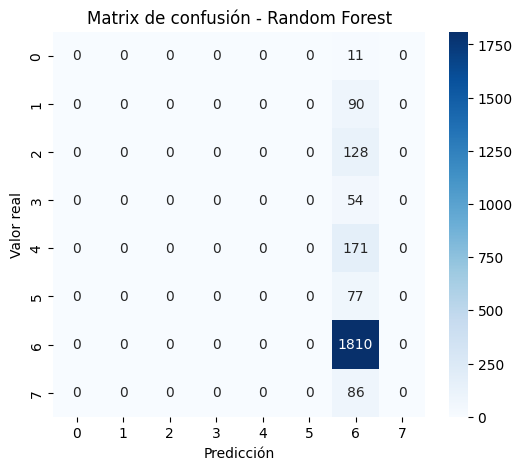

In [268]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Random Forest')
plt.show()


## Saving model

In [269]:
joblib.dump(lgr, "./models_saved/logregression.json")

['./models_saved/logregression.json']

## Bayesian optimization

Function that will be used during the optimization

In [270]:
def objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 10.0, log = True),
        "penalty": trial.suggest_categorical("penalty", ["l2"]),
        "max_iter": 1000,
        
        "multi_class": "multinomial",
        "random_state": seed,
        "n_jobs": -1
    }

    model = LogisticRegression(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [271]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-15 18:10:01,969] A new study created in memory with name: no-name-1c08dc21-26fd-49a5-a1f2-4ec314ffde8d
C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[I 2025-04-15 18:10:04,399] Trial 0 finished with value: 0.637175260344568 and parameters: {'C': 0.11914653758031543, 'penalty': 'l2'}. Best is trial 0 with value: 0.637175260344568.
C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave

In [272]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'C': 0.11914653758031543, 'penalty': 'l2'}


In [273]:
rfc = LogisticRegression(**optimization.best_params)
rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

In [274]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.7457766790276061
F1 score: 0.637175260344568


In [275]:
joblib.dump(rfc, "./models_saved/logregression_opt.json")

['./models_saved/logregression_opt.json']